In [ ]:
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
import pandas as pd
from matplotlib import pyplot as plt

In [ ]:
iris = load_iris()

In [ ]:

_df = pd.DataFrame(iris.data, columns=iris.feature_names)
print(_df.head())


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [ ]:
_df = _df[["petal length (cm)", "petal width (cm)"]]
print(_df.head())

   petal length (cm)  petal width (cm)
0                1.4               0.2
1                1.4               0.2
2                1.3               0.2
3                1.5               0.2
4                1.4               0.2


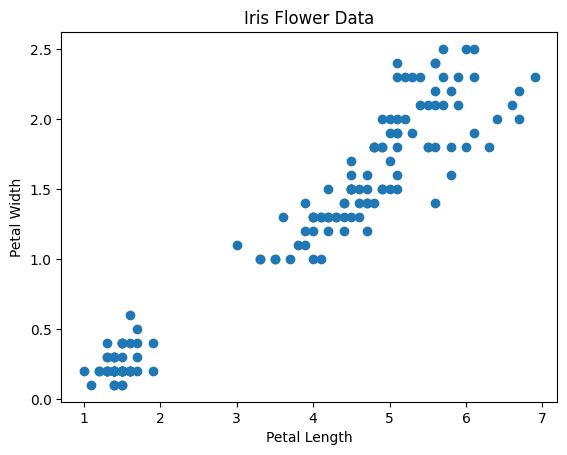

In [ ]:
plt.scatter(_df['petal length (cm)'], _df['petal width (cm)'])
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('Iris Flower Data')
plt.show()


In [ ]:
km = KMeans(n_clusters=3)
y_predicted = km.fit_predict(_df)

In [ ]:
_df['cluster'] = y_predicted
print(_df.head())

   petal length (cm)  petal width (cm)  cluster
0                1.4               0.2        1
1                1.4               0.2        1
2                1.3               0.2        1
3                1.5               0.2        1
4                1.4               0.2        1


In [ ]:
print(km.cluster_centers_)

[[5.59583333 2.0375    ]
 [1.462      0.246     ]
 [4.26923077 1.34230769]]


In [ ]:
_df1 = _df[_df.cluster == 0]
_df2 = _df[_df.cluster == 1]
_df3 = _df[_df.cluster == 2]

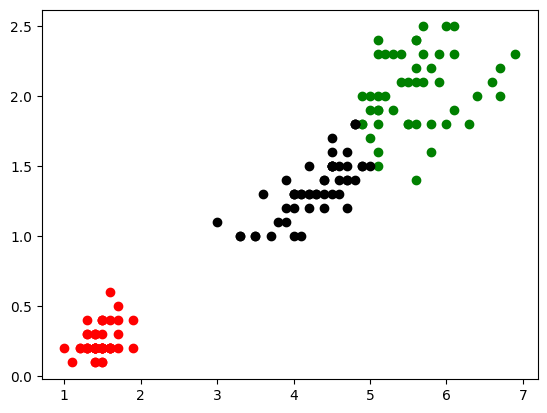

In [ ]:
plt.scatter(_df1['petal length (cm)'], _df1['petal width (cm)'], color='green')
plt.scatter(_df2['petal length (cm)'], _df2['petal width (cm)'], color='red')
plt.scatter(_df3['petal length (cm)'], _df3['petal width (cm)'], color='black')


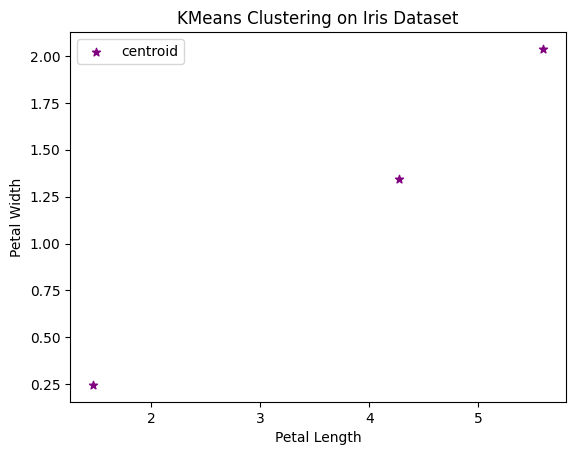

In [ ]:
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1], color='purple', marker='*', label='centroid')

plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.legend()
plt.title('KMeans Clustering on Iris Dataset')
plt.show()

In [ ]:
sse = []
k_rng = range(1, 10)

for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(_df[['petal length (cm)', 'petal width (cm)']])
    sse.append(km.inertia_)

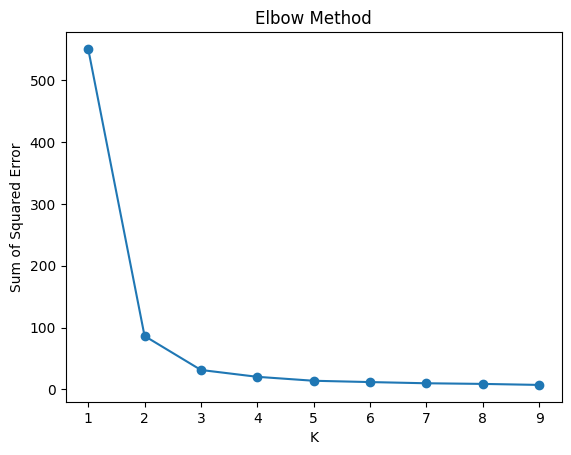

In [ ]:
plt.xlabel('K')
plt.ylabel('Sum of Squared Error')
plt.title('Elbow Method')
plt.plot(k_rng, sse, marker='o')
plt.show()